This notebook is to display and compare the results I personally conducted and the results found by the paper. This is to make sure what we're getting is correct!

## Import libraries

In [2]:
import matplotlib.pyplot as plt

In [3]:
# Quick code to load json files and get stats
import json
import re
def getStats( filename ):
    with open( filename, 'r') as file:
        data = json.load(file)

    X = []
    response50 = []
    response95 = []
    hitrate = []
    throughput = []
    for key in data:
        X.append( key )

        key_data = data[key]
        raw = key_data["raw"]

        # print( raw )
        match = re.search(r'/.*50\.00\% in (\d+\.\d+) secs.*95\.00\% in (\d+\.\d+) secs', raw, flags = re.DOTALL)
        response50.append( float( match.group(1) ) )
        response95.append( float( match.group(2) ) )

        if( "hit_rate" in key_data ):
            hitrate.append( key_data["hit_rate"] )
        throughput.append( key_data["throughput"] )

    out = {"50": response50, "95":response95,"hit_rate":hitrate,"throughput":throughput}
    return X, out

In [4]:
def plotStats( X, plots, xLabel, yLabel, title ):

    for label, plot in plots:
        plt.plot(x, plot, label=label )
    
    plt.grid()
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

## Cache Size Experiment

The reported experiment is this:

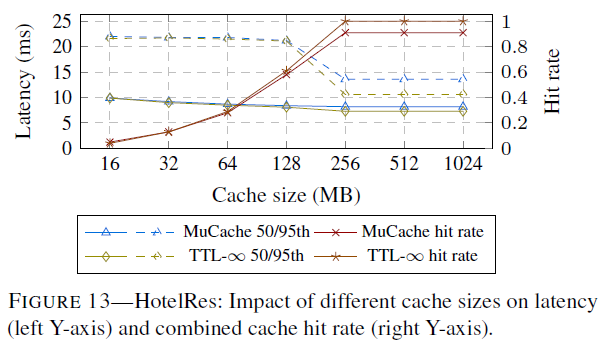

Our results are as follows:


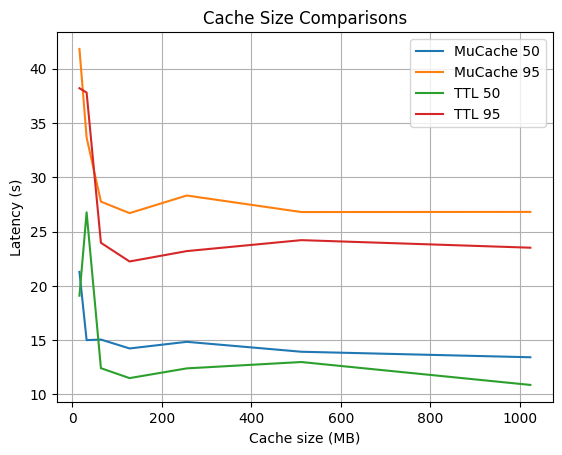

In [11]:
x = [16,32,64,128,256,512,1024]

# m510
_, mucache_out = getStats("hotel-md-510-1000.json")
_, ttl_out = getStats("hotel-md-upper-510-1000.json")

# d430
# _, mucache50, mucache95 = getStats("hotel-md.json")
# _, ttl50, ttl95 = getStats("hotel-md-upper.json")

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Cache size (MB)", "Latency (s)", "Cache Size Comparisons" )

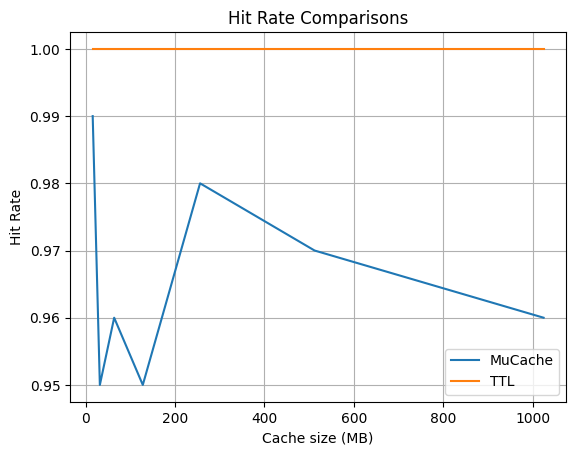

In [47]:
# Also plot the hitrate
#print( mucache_out["hit_rate"] )
plots = [["MuCache", [ float( hr["frontend"] ) for hr in mucache_out["hit_rate"]]],
         ["TTL", [ float( hr["frontend"] ) for hr in ttl_out["hit_rate"]]]
        ]
plotStats( x, plots, "Cache size (MB)", "Hit Rate", "Hit Rate Comparisons" )

### Analysis
Comparing the paper's graphs to our graphs, we can see that MuCache and TTL share similar values which is the same for the charts. However, the recorded trends in the paper such as the increase are not reflected in these experiments. In addition, the latency is in terms of seconds, not milliseconds.

## Microbenchmark

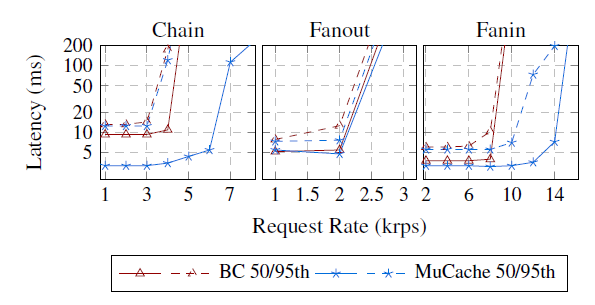

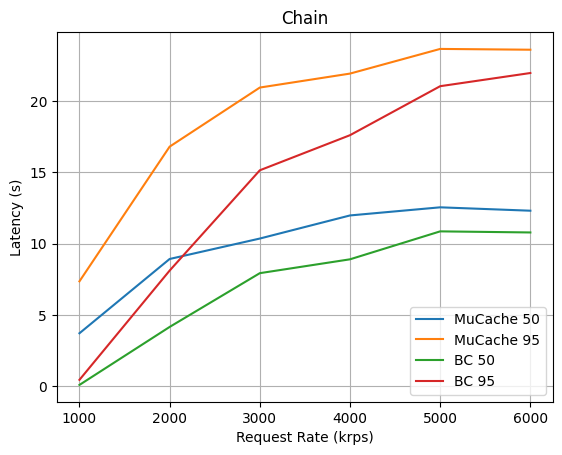

In [57]:
# Chain
x, mucache_out = getStats( "chain-510.json" )
_, bc_out = getStats( "chain-baseline-510.json" )

# print( mucache_out["50"] )
# chain_x = [1000,2000,3000,4000,5000,6000]
# chain_bc50 = [0.0071, 0.2382,2.6061,4.7698,5.9428,7.1235]
# chain_bc95 = [0.1902,5.3816,12.0952,14.9024,18.2335,18.7375]
# chain_mucache50 = [0.0084,3.7226,7.0437,8.5453,10.1613,10.0352]
# chain_mucache50 = [0.2270,10.2434,16.1354,19.3725,21.4978,22.0475]


# mucache50 = [8.1552, 8.2862,6.7958,7.7780,7.2911,8.1013,7.6966]
# mucache95 = [14.8294,15.4415,13.7228,14.9335,14.4478,15.0271,14.8589]

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "Chain" )

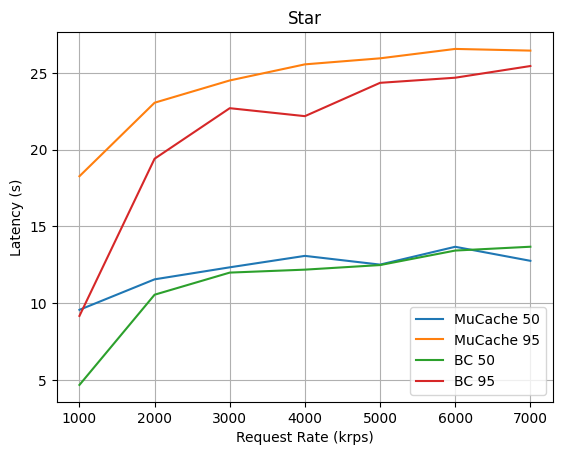

In [8]:
# Fanout/Star
x, mucache_out = getStats( "star-510.json" )
_, bc_out = getStats( "star-baseline-510.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "Star" )

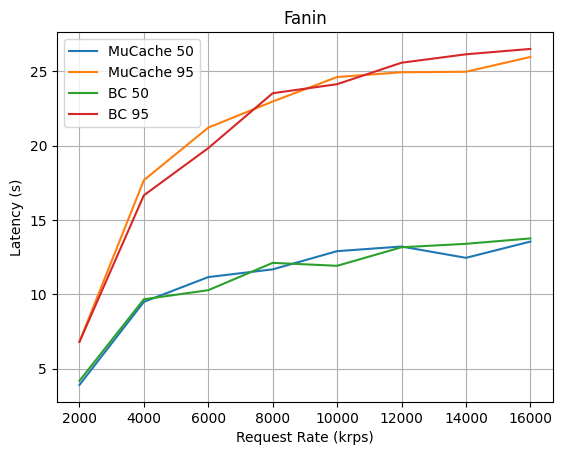

In [60]:
# Fanin
x, mucache_out = getStats( "fanin-510.json" )
_, bc_out = getStats( "fanin-baseline-510.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "Fanin" )

### Analysis
Compared to the paper's results, it seems like MuCache doesn't give any beneficial advantages. In fact, sometimes it does worse than the base case.

## Hit Rate

In [ ]:
# TODO new file
# Fanin
x, mucache_out = getStats( "fanin-510.json" )
_, bc_out = getStats( "fanin-baseline-510.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]SocialMedia
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "Fanin" )

## Real World Applications

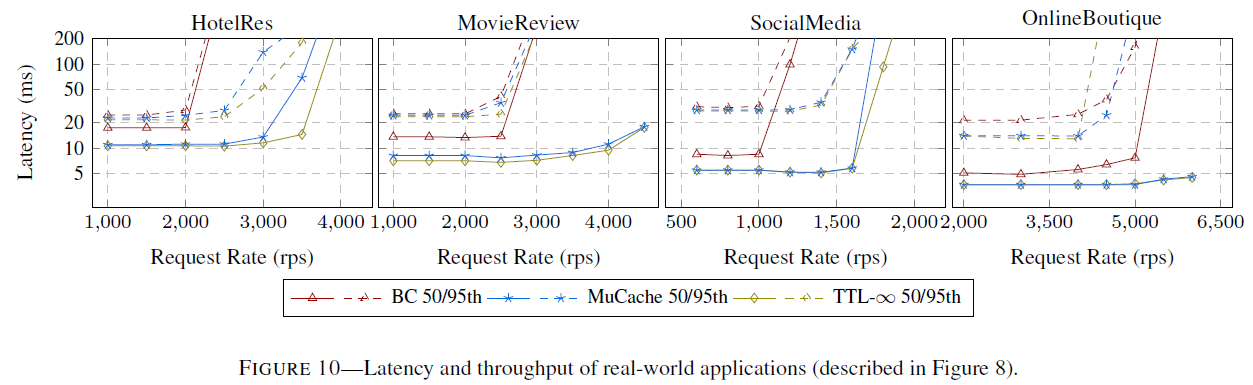

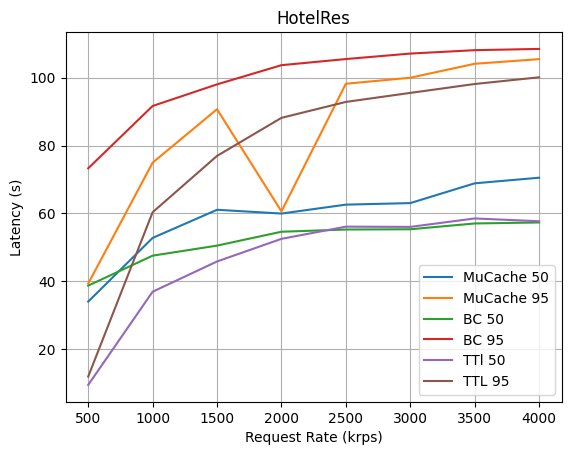

In [64]:
# HotelRes
x, mucache_out = getStats( "hotel-510.json" )
_, bc_out = getStats( "hotel-baseline-510.json" )
_, ttl_out = getStats( "hotel-upper-510.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTl 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "HotelRes" )

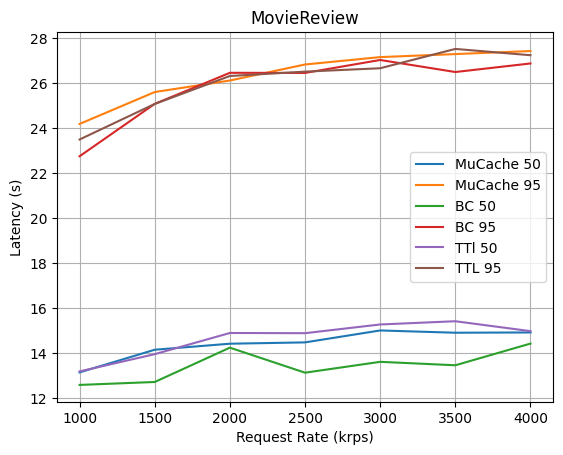

In [67]:
# MovieReview
x, mucache_out = getStats( "movie-510.json" )
_, bc_out = getStats( "movie-baseline-510.json" )
_, ttl_out = getStats( "movie-upper-510.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTl 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "MovieReview" )

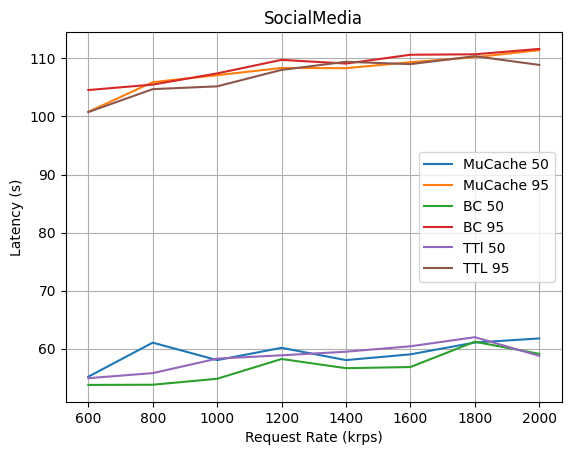

In [68]:
# SocialMedia
x, mucache_out = getStats( "social-510.json" )
_, bc_out = getStats( "social-baseline-510.json" )
_, ttl_out = getStats( "social-upper-510.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTl 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "SocialMedia" )

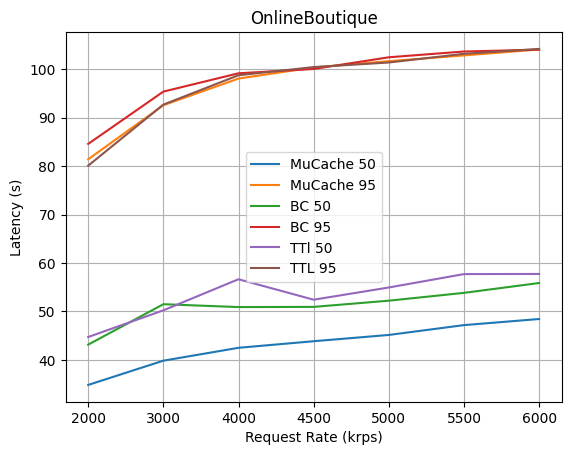

In [12]:
# OnlineBoutique (REDO)
x, mucache_out = getStats( "boutique-510.json" )
_, bc_out = getStats( "boutique-baseline-510.json" )
_, ttl_out = getStats( "boutique-upper-510.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTl 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "OnlineBoutique" )

### Analysis
There is slight improvement with MuCache, but not much compared to the paper. Though, it seems like the range of the tests are larger in the paper, might try that as well if time allows it

## Different TTL Baselines

DIDNT DO, DO IT